# Chapter 1: The Intersection of Physics and Learning
## Practical: Measuring Entropy in Data

This notebook demonstrates the estimation of entropy from a continuous probability distribution,
illustrating the bias-variance tradeoff in action.

### Setup and Data Generation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data from a 1D Gaussian
np.random.seed(42)
data = np.random.normal(0, 1, size=1000)

### Histogram Entropy Estimator

In [2]:
def entropy_histogram(data, bins=20):
    """Estimate entropy using histogram binning."""
    counts, _ = np.histogram(data, bins=bins, density=False)
    p = counts / np.sum(counts)
    p = p[p > 0]  # remove zeros
    return -np.sum(p * np.log(p))

### Compare Different Bin Numbers

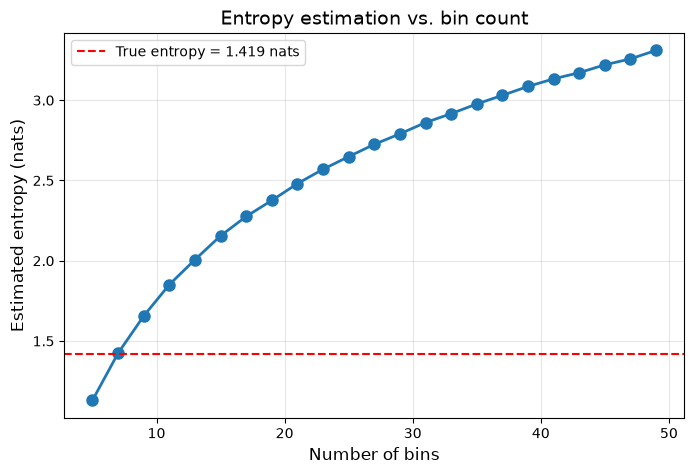

In [3]:
bins_range = np.arange(5, 50, 2)
entropies = [entropy_histogram(data, b) for b in bins_range]

plt.figure(figsize=(8, 5))
plt.plot(bins_range, entropies, 'o-', linewidth=2, markersize=8)
plt.xlabel('Number of bins', fontsize=12)
plt.ylabel('Estimated entropy (nats)', fontsize=12)
plt.title('Entropy estimation vs. bin count', fontsize=14)
plt.axhline(y=0.5 * np.log(2 * np.pi * np.e), color='red', linestyle='--', 
            label='True entropy = 1.419 nats')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Observations

- The estimate oscillates around the true value (1.419 nats).
- Too few bins cause high bias (smoothing out structure).
- Too many bins lead to high variance (many empty bins).
- This is precisely the bias-variance tradeoff in action.